In [1]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("ModelEvaluation") \
    .master("local[2]") \
    .config("spark.driver.host", "127.0.0.1") \
    .config("spark.driver.bindAddress", "127.0.0.1") \
    .getOrCreate()

print("Spark Started ")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/03/03 09:03:32 WARN Utils: Your hostname, vasu, resolves to a loopback address: 127.0.0.1; using 10.255.255.254 instead (on interface lo)
26/03/03 09:03:32 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/03 09:03:33 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/03/03 09:03:33 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


Spark Started 


In [2]:
test = spark.read.parquet("data/final/test_dataset")
print("Test Data Loaded:", test.count())

Test Data Loaded: 856408


In [3]:
from pyspark.ml.regression import LinearRegressionModel, RandomForestRegressionModel, GBTRegressionModel, DecisionTreeRegressionModel

model_lr = LinearRegressionModel.load("models/linear_regression_model")
model_rf = RandomForestRegressionModel.load("models/random_forest_model")
model_gbt = GBTRegressionModel.load("models/gbt_model")
model_dt = DecisionTreeRegressionModel.load("models/decision_tree_model")

print("All Models Loaded Successfully ")

All Models Loaded Successfully 


In [4]:
from pyspark.ml.evaluation import RegressionEvaluator

evaluator = RegressionEvaluator(
    labelCol="trips",
    predictionCol="prediction"
)

models = {
    "Linear Regression": model_lr,
    "Random Forest": model_rf,
    "Gradient Boosted Trees": model_gbt,
    "Decision Tree": model_dt
}

for name, model in models.items():
    predictions = model.transform(test)
    rmse = evaluator.evaluate(predictions, {evaluator.metricName: "rmse"})
    r2 = evaluator.evaluate(predictions, {evaluator.metricName: "r2"})
    print(f"{name} → RMSE: {rmse}, R2: {r2}")

26/03/03 09:04:39 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
                                                                                

Linear Regression → RMSE: 32370.49167993903, R2: 0.94564870080334


Random Forest → RMSE: 29717.281310596914, R2: 0.9541932490478142


Gradient Boosted Trees → RMSE: 29919.278066624436, R2: 0.9535684097835152
Decision Tree → RMSE: 30112.04430484163, R2: 0.9529681762976978


In [5]:
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.regression import RandomForestRegressor

In [6]:
rf = RandomForestRegressor(
    labelCol="trips",
    featuresCol="features"
)

In [7]:
paramGrid = ParamGridBuilder() \
    .addGrid(rf.numTrees, [30, 50]) \
    .addGrid(rf.maxDepth, [5, 10]) \
    .build()

In [8]:
evaluator = RegressionEvaluator(
    labelCol="trips",
    predictionCol="prediction",
    metricName="rmse"
)

In [9]:
crossval = CrossValidator(
    estimator=rf,
    estimatorParamMaps=paramGrid,
    evaluator=evaluator,
    numFolds=3,   
    parallelism=2
)

In [12]:
df = spark.read.parquet("data/final/mobility_ml_ready_v1")
print("Rows:", df.count())

Rows: 4280945


In [13]:
from pyspark.ml.feature import VectorAssembler

numeric_cols = [
    "pop_stay_at_home",
    "pop_not_stay_at_home",
    "mobility_ratio",
    "week",
    "month"
]

assembler = VectorAssembler(
    inputCols=numeric_cols,
    outputCol="features"
)

df = assembler.transform(df)
print("Features Created ")

Features Created 


In [14]:
train, test = df.randomSplit([0.8, 0.2], seed=42)

print("Train Rows:", train.count())
print("Test Rows:", test.count())

Train Rows: 3424537


[Stage 43:======================================>                   (2 + 1) / 3]

Test Rows: 856408


In [15]:
cv_model = crossval.fit(train)
print("Cross-Validation Training Completed ")

26/03/03 09:14:25 WARN BlockManager: Block rdd_180_0 already exists on this machine; not re-adding it
26/03/03 09:14:31 WARN MemoryStore: Not enough space to cache rdd_180_1 in memory! (computed 154.2 MiB so far)
26/03/03 09:14:31 WARN BlockManager: Persisting block rdd_180_1 to disk instead.
26/03/03 09:14:37 WARN MemoryStore: Not enough space to cache rdd_180_2 in memory! (computed 40.3 MiB so far)
26/03/03 09:14:37 WARN BlockManager: Persisting block rdd_180_2 to disk instead.
26/03/03 09:14:39 WARN MemoryStore: Not enough space to cache rdd_180_0 in memory! (computed 78.1 MiB so far)
26/03/03 09:14:39 WARN MemoryStore: Not enough space to cache rdd_180_0 in memory! (computed 78.1 MiB so far)
26/03/03 09:14:40 WARN MemoryStore: Not enough space to cache rdd_180_0 in memory! (computed 78.1 MiB so far)
26/03/03 09:14:41 WARN MemoryStore: Not enough space to cache rdd_213_0 in memory! (computed 68.0 MiB so far)
26/03/03 09:14:41 WARN BlockManager: Persisting block rdd_213_0 to disk ins

Cross-Validation Training Completed 


In [16]:
best_model = cv_model.bestModel

pred_cv = best_model.transform(test)

rmse_cv = evaluator.evaluate(pred_cv, {evaluator.metricName: "rmse"})
r2_cv = evaluator.evaluate(pred_cv, {evaluator.metricName: "r2"})

print("Tuned RF RMSE:", rmse_cv)
print("Tuned RF R2:", r2_cv)

[Stage 324:======================================>                  (2 + 1) / 3]

Tuned RF RMSE: 29717.152910600285
Tuned RF R2: 0.9541936448830792


In [17]:
predictions = best_model.transform(test)

In [19]:
!pip install numpy scikit-learn matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 3.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.2/114.2 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 11.3 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 11.6 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 362.6/362.6 kB 9.1 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 12.0 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 309.1/309.1 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 14.5 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 11.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.8/122.8 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 10.4 MB/s eta 0:00:00

In [22]:
!pip install "pandas>=2.2.0"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 11.4 MB/s eta 0:00:0000:0100:01


In [23]:
pred_pd = predictions.select("trips", "prediction").toPandas()
print("Collected predictions to Pandas ")

Collected predictions to Pandas 


In [24]:
import numpy as np
from sklearn.metrics import mean_squared_error

n_iterations = 200  
n_size = len(pred_pd)

rmse_scores = []

for i in range(n_iterations):
    sample = pred_pd.sample(n=n_size, replace=True)
    rmse = np.sqrt(mean_squared_error(sample["trips"], sample["prediction"]))
    rmse_scores.append(rmse)

print("Bootstrap completed ")

Bootstrap completed 


In [25]:
lower = np.percentile(rmse_scores, 2.5)
upper = np.percentile(rmse_scores, 97.5)

print("Bootstrap RMSE Mean:", np.mean(rmse_scores))
print("95% Confidence Interval:", (lower, upper))

Bootstrap RMSE Mean: 29710.122603936856
95% Confidence Interval: (np.float64(29586.153144050968), np.float64(29813.68383873089))


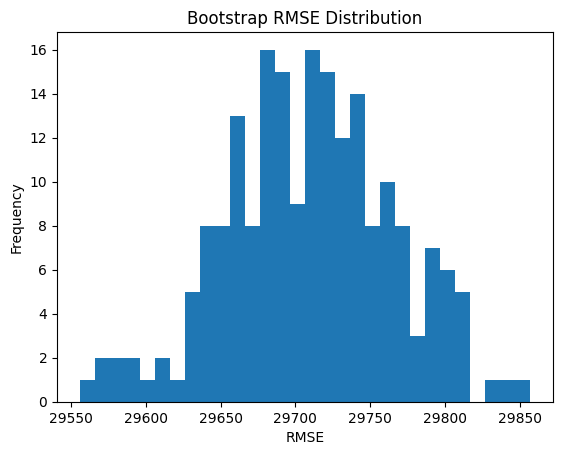

In [26]:
import matplotlib.pyplot as plt

plt.hist(rmse_scores, bins=30)
plt.title("Bootstrap RMSE Distribution")
plt.xlabel("RMSE")
plt.ylabel("Frequency")
plt.show()

In [29]:
test = spark.read.parquet("data/final/test_dataset")
print("Test Loaded ")

Test Loaded 


In [30]:
from pyspark.ml.regression import RandomForestRegressionModel

model_rf = RandomForestRegressionModel.load("models/random_forest_model")
print("RF Model Loaded ")

RF Model Loaded 


In [31]:
pred_rf = model_rf.transform(test)
print("Predictions Created ")

Predictions Created 


In [32]:
from pyspark.ml.evaluation import RegressionEvaluator

evaluator_mae = RegressionEvaluator(
    labelCol="trips",
    predictionCol="prediction",
    metricName="mae"
)

mae_rf = evaluator_mae.evaluate(pred_rf)

print("Random Forest MAE:", mae_rf)

[Stage 333:======================================>                  (2 + 1) / 3]

Random Forest MAE: 17851.881951198648


In [34]:
from pyspark.sql.functions import col, abs, when

mape_df = pred_rf.withColumn(
    "abs_percentage_error",
    when(
        col("trips") != 0,
        abs((col("trips") - col("prediction")) / col("trips"))
    ).otherwise(None)
)

mape = mape_df.selectExpr("avg(abs_percentage_error)").collect()[0][0] * 100

print("Random Forest MAPE (%):", mape)

[Stage 336:======================================>                  (2 + 1) / 3]

Random Forest MAPE (%): 18.914548582987994


In [35]:
df.selectExpr("avg(trips)").show()

+-----------------+
|       avg(trips)|
+-----------------+
|134257.1592973047|
+-----------------+



In [36]:
# Take safe sample for plotting
sample_pd = pred_rf.select("trips", "prediction") \
    .sample(fraction=0.05, seed=42) \
    .toPandas()

print("Sample collected for plotting ")

Sample collected for plotting 


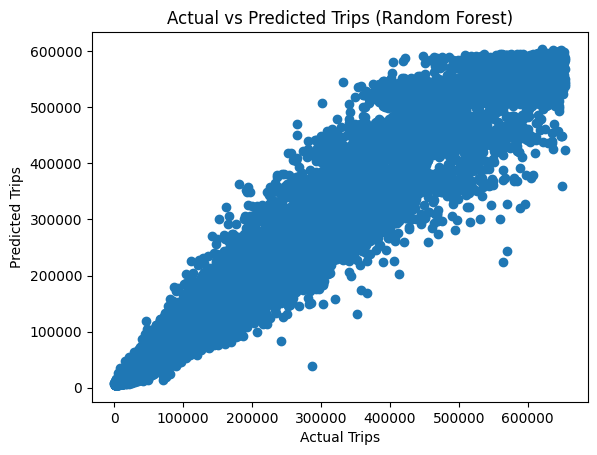

In [37]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(sample_pd["trips"], sample_pd["prediction"])
plt.xlabel("Actual Trips")
plt.ylabel("Predicted Trips")
plt.title("Actual vs Predicted Trips (Random Forest)")
plt.show()

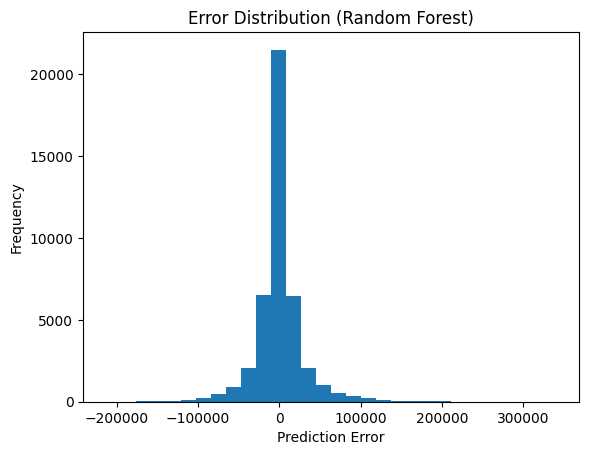

In [38]:
sample_pd["error"] = sample_pd["trips"] - sample_pd["prediction"]

plt.figure()
plt.hist(sample_pd["error"], bins=30)
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.title("Error Distribution (Random Forest)")
plt.show()

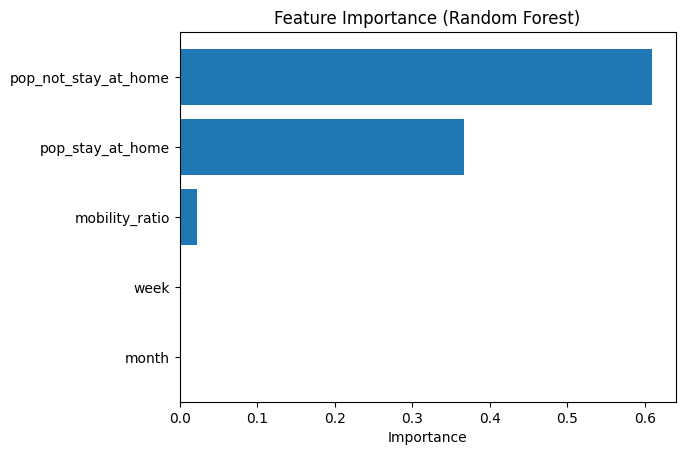

In [39]:
import pandas as pd

importances = model_rf.featureImportances.toArray()

feature_names = [
    "pop_stay_at_home",
    "pop_not_stay_at_home",
    "mobility_ratio",
    "week",
    "month"
]

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

plt.figure()
plt.barh(importance_df["feature"], importance_df["importance"])
plt.xlabel("Importance")
plt.title("Feature Importance (Random Forest)")
plt.gca().invert_yaxis()
plt.show()

In [40]:
from pyspark.ml.regression import RandomForestRegressor
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.sql.functions import rand

In [41]:
rf = RandomForestRegressor(
    labelCol="trips",
    featuresCol="features",
    numTrees=30,
    maxDepth=5,
    seed=42
)

evaluator = RegressionEvaluator(
    labelCol="trips",
    predictionCol="prediction",
    metricName="rmse"
)

rmse_scores = []

for i in range(5):   # 5 perturbations
    print(f"Iteration {i+1}")

    # Random 90% sample of training data
    perturbed_train = train.sample(fraction=0.9, seed=i)

    # Train model
    model = rf.fit(perturbed_train)

    # Predict on SAME test set
    preds = model.transform(test)

    # Evaluate
    rmse = evaluator.evaluate(preds)

    rmse_scores.append(rmse)

    print("RMSE:", rmse)

print("Stability Analysis Completed ")

Iteration 1


26/03/03 09:57:01 WARN MemoryStore: Not enough space to cache rdd_978_1 in memory! (computed 43.6 MiB so far)
26/03/03 09:57:01 WARN BlockManager: Persisting block rdd_978_1 to disk instead.
26/03/03 09:57:01 WARN MemoryStore: Not enough space to cache rdd_978_0 in memory! (computed 68.0 MiB so far)
26/03/03 09:57:01 WARN BlockManager: Persisting block rdd_978_0 to disk instead.
26/03/03 09:57:05 WARN MemoryStore: Not enough space to cache rdd_978_1 in memory! (computed 234.0 MiB so far)
26/03/03 09:57:05 WARN MemoryStore: Not enough space to cache rdd_978_0 in memory! (computed 156.0 MiB so far)
26/03/03 09:57:14 WARN MemoryStore: Not enough space to cache rdd_978_1 in memory! (computed 104.0 MiB so far)
26/03/03 09:57:14 WARN MemoryStore: Not enough space to cache rdd_978_0 in memory! (computed 104.0 MiB so far)
26/03/03 09:57:18 WARN MemoryStore: Not enough space to cache rdd_978_1 in memory! (computed 104.0 MiB so far)
26/03/03 09:57:18 WARN MemoryStore: Not enough space to cache r

RMSE: 33332.51506530989
Iteration 2


26/03/03 09:58:04 WARN MemoryStore: Not enough space to cache rdd_1022_0 in memory! (computed 43.6 MiB so far)
26/03/03 09:58:04 WARN BlockManager: Persisting block rdd_1022_0 to disk instead.
26/03/03 09:58:05 WARN MemoryStore: Not enough space to cache rdd_1022_1 in memory! (computed 156.0 MiB so far)
26/03/03 09:58:05 WARN BlockManager: Persisting block rdd_1022_1 to disk instead.
26/03/03 09:58:08 WARN MemoryStore: Not enough space to cache rdd_1022_1 in memory! (computed 234.0 MiB so far)
26/03/03 09:58:08 WARN MemoryStore: Not enough space to cache rdd_1022_0 in memory! (computed 156.0 MiB so far)
26/03/03 09:58:17 WARN MemoryStore: Not enough space to cache rdd_1022_1 in memory! (computed 104.0 MiB so far)
26/03/03 09:58:17 WARN MemoryStore: Not enough space to cache rdd_1022_0 in memory! (computed 104.0 MiB so far)
26/03/03 09:58:21 WARN MemoryStore: Not enough space to cache rdd_1022_1 in memory! (computed 104.0 MiB so far)
26/03/03 09:58:21 WARN MemoryStore: Not enough space 

RMSE: 33526.221085364195
Iteration 3


...

RMSE: 33270.60858455478
Iteration 4


26/03/03 10:00:07 WARN MemoryStore: Not enough space to cache rdd_1110_0 in memory! (computed 43.6 MiB so far)
26/03/03 10:00:07 WARN BlockManager: Persisting block rdd_1110_0 to disk instead.
26/03/03 10:00:08 WARN MemoryStore: Not enough space to cache rdd_1110_1 in memory! (computed 156.0 MiB so far)
26/03/03 10:00:08 WARN BlockManager: Persisting block rdd_1110_1 to disk instead.
26/03/03 10:00:11 WARN MemoryStore: Not enough space to cache rdd_1110_1 in memory! (computed 234.0 MiB so far)
26/03/03 10:00:11 WARN MemoryStore: Not enough space to cache rdd_1110_0 in memory! (computed 156.0 MiB so far)
26/03/03 10:00:20 WARN MemoryStore: Not enough space to cache rdd_1110_0 in memory! (computed 104.0 MiB so far)
26/03/03 10:00:20 WARN MemoryStore: Not enough space to cache rdd_1110_1 in memory! (computed 104.0 MiB so far)
26/03/03 10:00:24 WARN MemoryStore: Not enough space to cache rdd_1110_0 in memory! (computed 104.0 MiB so far)
26/03/03 10:00:24 WARN MemoryStore: Not enough space 

RMSE: 33392.18108072621
Iteration 5


26/03/03 10:01:08 WARN MemoryStore: Not enough space to cache rdd_1154_0 in memory! (computed 43.6 MiB so far)
26/03/03 10:01:08 WARN BlockManager: Persisting block rdd_1154_0 to disk instead.
26/03/03 10:01:09 WARN MemoryStore: Not enough space to cache rdd_1154_1 in memory! (computed 156.0 MiB so far)
26/03/03 10:01:09 WARN BlockManager: Persisting block rdd_1154_1 to disk instead.
26/03/03 10:01:12 WARN MemoryStore: Not enough space to cache rdd_1154_1 in memory! (computed 234.0 MiB so far)
26/03/03 10:01:12 WARN MemoryStore: Not enough space to cache rdd_1154_0 in memory! (computed 156.0 MiB so far)
26/03/03 10:01:21 WARN MemoryStore: Not enough space to cache rdd_1154_0 in memory! (computed 104.0 MiB so far)
26/03/03 10:01:21 WARN MemoryStore: Not enough space to cache rdd_1154_1 in memory! (computed 104.0 MiB so far)
26/03/03 10:01:25 WARN MemoryStore: Not enough space to cache rdd_1154_0 in memory! (computed 104.0 MiB so far)
26/03/03 10:01:25 WARN MemoryStore: Not enough space 

RMSE: 33309.08557705798
Stability Analysis Completed 


In [42]:
import numpy as np

mean_rmse = np.mean(rmse_scores)
std_rmse = np.std(rmse_scores)

print("Mean RMSE:", mean_rmse)
print("RMSE Std Dev:", std_rmse)

Mean RMSE: 33366.122278602605
RMSE Std Dev: 89.2369709858606


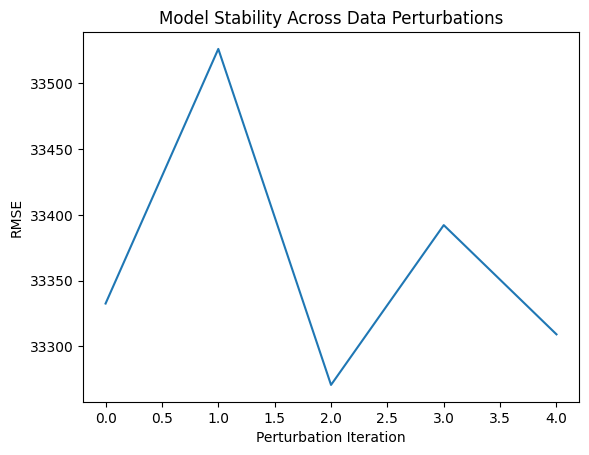

In [43]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(rmse_scores)
plt.xlabel("Perturbation Iteration")
plt.ylabel("RMSE")
plt.title("Model Stability Across Data Perturbations")
plt.show()

In [44]:
import time

from pyspark.ml.regression import RandomForestRegressor

rf = RandomForestRegressor(
    labelCol="trips",
    featuresCol="features",
    numTrees=30,
    maxDepth=5
)

partitions_list = [10, 20, 50, 100]

strong_results = []

for p in partitions_list:
    print(f"\nTesting with {p} partitions")

    df_scaled = train.repartition(p)

    start = time.time()
    model = rf.fit(df_scaled)
    end = time.time()

    duration = end - start

    print("Time:", duration)

    strong_results.append((p, duration))

print("Strong Scaling Completed ")


Testing with 10 partitions


26/03/03 10:03:38 WARN MemoryStore: Not enough space to cache rdd_1201_5 in memory! (computed 43.6 MiB so far)
26/03/03 10:03:38 WARN BlockManager: Persisting block rdd_1201_5 to disk instead.
26/03/03 10:03:39 WARN MemoryStore: Not enough space to cache rdd_1201_5 in memory! (computed 28.9 MiB so far)
26/03/03 10:03:39 WARN MemoryStore: Not enough space to cache rdd_1201_6 in memory! (computed 5.4 MiB so far)
26/03/03 10:03:39 WARN BlockManager: Persisting block rdd_1201_6 to disk instead.
26/03/03 10:03:40 WARN MemoryStore: Not enough space to cache rdd_1201_7 in memory! (computed 28.9 MiB so far)
26/03/03 10:03:40 WARN BlockManager: Persisting block rdd_1201_7 to disk instead.
26/03/03 10:03:41 WARN MemoryStore: Not enough space to cache rdd_1201_6 in memory! (computed 28.9 MiB so far)
26/03/03 10:03:41 WARN MemoryStore: Not enough space to cache rdd_1201_7 in memory! (computed 28.9 MiB so far)
26/03/03 10:03:41 WARN MemoryStore: Not enough space to cache rdd_1201_8 in memory! (comp

Time: 42.08745980262756

Testing with 20 partitions


26/03/03 10:04:19 WARN MemoryStore: Not enough space to cache rdd_1236_11 in memory! (computed 12.8 MiB so far)
26/03/03 10:04:19 WARN BlockManager: Persisting block rdd_1236_11 to disk instead.
26/03/03 10:04:20 WARN MemoryStore: Not enough space to cache rdd_1236_10 in memory! (computed 28.9 MiB so far)
26/03/03 10:04:20 WARN BlockManager: Persisting block rdd_1236_10 to disk instead.
26/03/03 10:04:20 WARN MemoryStore: Not enough space to cache rdd_1236_10 in memory! (computed 12.8 MiB so far)
26/03/03 10:04:20 WARN MemoryStore: Not enough space to cache rdd_1236_11 in memory! (computed 19.3 MiB so far)
26/03/03 10:04:20 WARN MemoryStore: Not enough space to cache rdd_1236_13 in memory! (computed 12.8 MiB so far)
26/03/03 10:04:20 WARN BlockManager: Persisting block rdd_1236_13 to disk instead.
26/03/03 10:04:21 WARN MemoryStore: Not enough space to cache rdd_1236_12 in memory! (computed 28.9 MiB so far)
26/03/03 10:04:21 WARN BlockManager: Persisting block rdd_1236_12 to disk inste

Time: 40.99847197532654

Testing with 50 partitions


26/03/03 10:05:01 WARN MemoryStore: Not enough space to cache rdd_1271_27 in memory! (computed 8.5 MiB so far)
26/03/03 10:05:01 WARN MemoryStore: Not enough space to cache rdd_1271_26 in memory! (computed 8.5 MiB so far)
26/03/03 10:05:01 WARN BlockManager: Persisting block rdd_1271_26 to disk instead.
26/03/03 10:05:01 WARN BlockManager: Persisting block rdd_1271_27 to disk instead.
26/03/03 10:05:01 WARN MemoryStore: Not enough space to cache rdd_1271_26 in memory! (computed 8.5 MiB so far)
26/03/03 10:05:01 WARN MemoryStore: Not enough space to cache rdd_1271_27 in memory! (computed 8.5 MiB so far)
26/03/03 10:05:02 WARN MemoryStore: Not enough space to cache rdd_1271_28 in memory! (computed 8.5 MiB so far)
26/03/03 10:05:02 WARN BlockManager: Persisting block rdd_1271_28 to disk instead.
26/03/03 10:05:02 WARN MemoryStore: Not enough space to cache rdd_1271_29 in memory! (computed 8.5 MiB so far)
26/03/03 10:05:02 WARN BlockManager: Persisting block rdd_1271_29 to disk instead.
26

Time: 44.20539689064026

Testing with 100 partitions


26/03/03 10:05:47 WARN MemoryStore: Not enough space to cache rdd_1306_52 in memory! (computed 8.5 MiB so far)
26/03/03 10:05:47 WARN BlockManager: Persisting block rdd_1306_52 to disk instead.
26/03/03 10:05:47 WARN MemoryStore: Not enough space to cache rdd_1306_53 in memory! (computed 8.5 MiB so far)
26/03/03 10:05:47 WARN BlockManager: Persisting block rdd_1306_53 to disk instead.
26/03/03 10:05:47 WARN MemoryStore: Not enough space to cache rdd_1306_52 in memory! (computed 8.5 MiB so far)
26/03/03 10:05:47 WARN MemoryStore: Not enough space to cache rdd_1306_53 in memory! (computed 8.5 MiB so far)
26/03/03 10:05:47 WARN MemoryStore: Not enough space to cache rdd_1306_54 in memory! (computed 8.5 MiB so far)
26/03/03 10:05:47 WARN BlockManager: Persisting block rdd_1306_54 to disk instead.
26/03/03 10:05:47 WARN MemoryStore: Not enough space to cache rdd_1306_55 in memory! (computed 8.5 MiB so far)
26/03/03 10:05:47 WARN BlockManager: Persisting block rdd_1306_55 to disk instead.
26

Time: 49.71701741218567
Strong Scaling Completed 


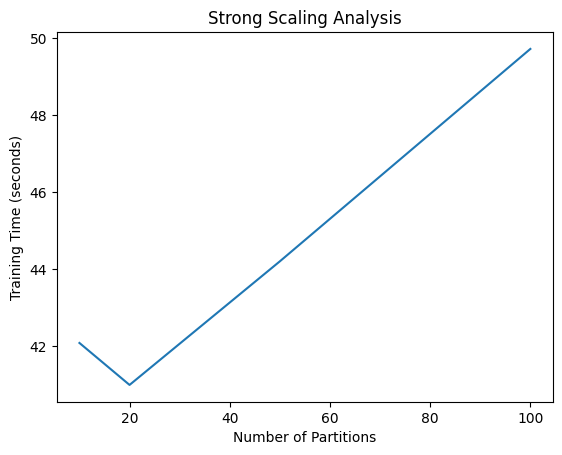

In [45]:
import matplotlib.pyplot as plt

partitions = [x[0] for x in strong_results]
times = [x[1] for x in strong_results]

plt.figure()
plt.plot(partitions, times)
plt.xlabel("Number of Partitions")
plt.ylabel("Training Time (seconds)")
plt.title("Strong Scaling Analysis")
plt.show()

In [46]:
fractions = [0.25, 0.5, 0.75, 1.0]

weak_results = []

for f in fractions:
    print(f"\nTesting with {int(f*100)}% data")

    subset = train.sample(fraction=f, seed=42)

    subset = subset.repartition(int(50 * f) + 1)

    start = time.time()
    model = rf.fit(subset)
    end = time.time()

    duration = end - start

    print("Time:", duration)

    weak_results.append((f, duration))

print("Weak Scaling Completed ")


Testing with 25% data


Time: 17.13338804244995

Testing with 50% data


Time: 23.888229608535767

Testing with 75% data


26/03/03 10:09:08 WARN MemoryStore: Not enough space to cache rdd_1411_27 in memory! (computed 8.5 MiB so far)
26/03/03 10:09:08 WARN BlockManager: Persisting block rdd_1411_27 to disk instead.
26/03/03 10:09:08 WARN MemoryStore: Not enough space to cache rdd_1411_27 in memory! (computed 8.5 MiB so far)
26/03/03 10:09:08 WARN MemoryStore: Not enough space to cache rdd_1411_28 in memory! (computed 1076.4 KiB so far)
26/03/03 10:09:08 WARN BlockManager: Persisting block rdd_1411_28 to disk instead.
26/03/03 10:09:08 WARN MemoryStore: Not enough space to cache rdd_1411_29 in memory! (computed 8.5 MiB so far)
26/03/03 10:09:08 WARN BlockManager: Persisting block rdd_1411_29 to disk instead.
26/03/03 10:09:08 WARN MemoryStore: Not enough space to cache rdd_1411_28 in memory! (computed 1076.4 KiB so far)
26/03/03 10:09:08 WARN MemoryStore: Not enough space to cache rdd_1411_29 in memory! (computed 8.5 MiB so far)
26/03/03 10:09:08 WARN MemoryStore: Not enough space to cache rdd_1411_30 in me

Time: 34.16568183898926

Testing with 100% data


26/03/03 10:09:43 WARN MemoryStore: Not enough space to cache rdd_1446_26 in memory! (computed 12.8 MiB so far)
26/03/03 10:09:43 WARN BlockManager: Persisting block rdd_1446_26 to disk instead.
26/03/03 10:09:43 WARN MemoryStore: Not enough space to cache rdd_1446_27 in memory! (computed 12.8 MiB so far)
26/03/03 10:09:43 WARN BlockManager: Persisting block rdd_1446_27 to disk instead.
26/03/03 10:09:43 WARN MemoryStore: Not enough space to cache rdd_1446_27 in memory! (computed 8.5 MiB so far)
26/03/03 10:09:43 WARN MemoryStore: Not enough space to cache rdd_1446_29 in memory! (computed 3.6 MiB so far)
26/03/03 10:09:43 WARN BlockManager: Persisting block rdd_1446_29 to disk instead.
26/03/03 10:09:43 WARN MemoryStore: Not enough space to cache rdd_1446_28 in memory! (computed 12.8 MiB so far)
26/03/03 10:09:43 WARN BlockManager: Persisting block rdd_1446_28 to disk instead.
26/03/03 10:09:43 WARN MemoryStore: Not enough space to cache rdd_1446_29 in memory! (computed 5.4 MiB so far)

Time: 44.23541760444641
Weak Scaling Completed 


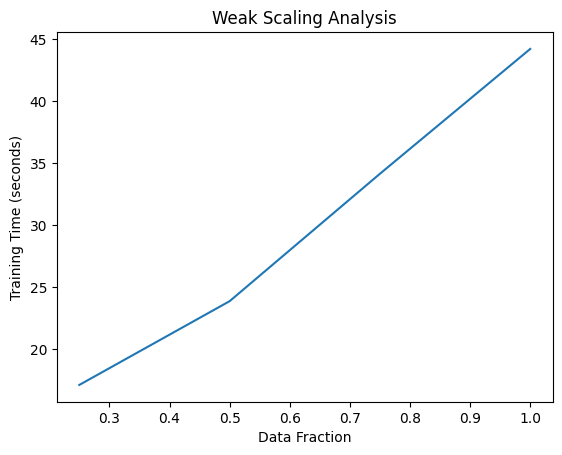

In [47]:
fractions_plot = [x[0] for x in weak_results]
times_plot = [x[1] for x in weak_results]

plt.figure()
plt.plot(fractions_plot, times_plot)
plt.xlabel("Data Fraction")
plt.ylabel("Training Time (seconds)")
plt.title("Weak Scaling Analysis")
plt.show()

In [48]:
print("Shuffle Partitions:", spark.conf.get("spark.sql.shuffle.partitions"))

Shuffle Partitions: 200


In [49]:
spark.sparkContext.setLogLevel("INFO")

In [50]:
train.groupBy("level").count().show()

[Stage 607:======================================>                  (2 + 1) / 3]

+------+-------+
| level|  count|
+------+-------+
|County|3424537|
+------+-------+



In [51]:
configs = [
    {"numTrees": 10, "maxDepth": 5},
    {"numTrees": 50, "maxDepth": 10}
]

cost_results = []

for cfg in configs:
    print("\nTesting config:", cfg)

    rf = RandomForestRegressor(
        labelCol="trips",
        featuresCol="features",
        numTrees=cfg["numTrees"],
        maxDepth=cfg["maxDepth"]
    )

    start = time.time()
    model = rf.fit(train)
    end = time.time()

    duration = end - start

    preds = model.transform(test)

    evaluator = RegressionEvaluator(
        labelCol="trips",
        predictionCol="prediction",
        metricName="rmse"
    )

    rmse = evaluator.evaluate(preds)

    print("Time:", duration)
    print("RMSE:", rmse)

    cost_results.append((cfg, duration, rmse))

print("Cost-Performance Analysis Completed ")


Testing config: {'numTrees': 10, 'maxDepth': 5}


26/03/03 10:12:14 WARN MemoryStore: Not enough space to cache rdd_1485_0 in memory! (computed 70.0 MiB so far)
26/03/03 10:12:14 WARN BlockManager: Persisting block rdd_1485_0 to disk instead.
26/03/03 10:12:14 WARN MemoryStore: Not enough space to cache rdd_1485_1 in memory! (computed 105.0 MiB so far)
26/03/03 10:12:14 WARN BlockManager: Persisting block rdd_1485_1 to disk instead.
26/03/03 10:12:21 WARN MemoryStore: Not enough space to cache rdd_1485_2 in memory! (computed 5.7 MiB so far)
26/03/03 10:12:21 WARN BlockManager: Persisting block rdd_1485_2 to disk instead.
26/03/03 10:12:24 WARN MemoryStore: Not enough space to cache rdd_1485_1 in memory! (computed 70.0 MiB so far)
26/03/03 10:12:26 WARN MemoryStore: Not enough space to cache rdd_1485_1 in memory! (computed 70.0 MiB so far)
26/03/03 10:12:27 WARN MemoryStore: Not enough space to cache rdd_1485_1 in memory! (computed 70.0 MiB so far)
26/03/03 10:12:29 WARN MemoryStore: Not enough space to cache rdd_1485_1 in memory! (com

Time: 44.938724517822266
RMSE: 33316.08690558073

Testing config: {'numTrees': 50, 'maxDepth': 10}


26/03/03 10:12:59 WARN MemoryStore: Not enough space to cache rdd_1529_1 in memory! (computed 67.5 MiB so far)
26/03/03 10:12:59 WARN BlockManager: Persisting block rdd_1529_1 to disk instead.
26/03/03 10:12:59 WARN MemoryStore: Not enough space to cache rdd_1529_0 in memory! (computed 67.5 MiB so far)
26/03/03 10:12:59 WARN BlockManager: Persisting block rdd_1529_0 to disk instead.
26/03/03 10:13:04 WARN MemoryStore: Not enough space to cache rdd_1529_1 in memory! (computed 228.0 MiB so far)
26/03/03 10:13:05 WARN MemoryStore: Not enough space to cache rdd_1529_0 in memory! (computed 151.9 MiB so far)
26/03/03 10:13:15 WARN MemoryStore: Not enough space to cache rdd_1529_2 in memory! (computed 360.0 MiB so far)
26/03/03 10:13:15 WARN BlockManager: Persisting block rdd_1529_2 to disk instead.
26/03/03 10:13:17 WARN MemoryStore: Not enough space to cache rdd_1529_2 in memory! (computed 360.0 MiB so far)
26/03/03 10:13:20 WARN MemoryStore: Not enough space to cache rdd_1529_1 in memory! 

Time: 295.9068443775177
RMSE: 29717.152910600285
Cost-Performance Analysis Completed 


26/03/03 10:20:24 WARN MemoryStore: Not enough space to cache rdd_1632_0 in memory! (computed 43.6 MiB so far)
26/03/03 10:20:24 WARN BlockManager: Persisting block rdd_1632_0 to disk instead.
26/03/03 10:21:08 WARN MemoryStore: Not enough space to cache rdd_1676_0 in memory! (computed 43.6 MiB so far)
26/03/03 10:21:08 WARN BlockManager: Persisting block rdd_1676_0 to disk instead.
26/03/03 10:21:08 WARN MemoryStore: Not enough space to cache rdd_1676_1 in memory! (computed 156.0 MiB so far)
26/03/03 10:21:08 WARN BlockManager: Persisting block rdd_1676_1 to disk instead.
26/03/03 10:21:14 WARN MemoryStore: Not enough space to cache rdd_1676_2 in memory! (computed 28.9 MiB so far)
26/03/03 10:21:14 WARN BlockManager: Persisting block rdd_1676_2 to disk instead.
26/03/03 10:21:18 WARN MemoryStore: Not enough space to cache rdd_1676_1 in memory! (computed 104.0 MiB so far)
26/03/03 10:21:20 WARN MemoryStore: Not enough space to cache rdd_1676_1 in memory! (computed 104.0 MiB so far)
26/

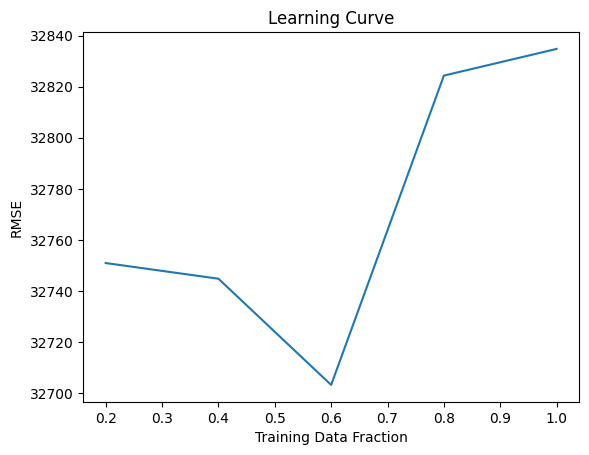

In [52]:
import numpy as np
import matplotlib.pyplot as plt
from pyspark.ml.regression import RandomForestRegressor
from pyspark.ml.evaluation import RegressionEvaluator

fractions = [0.2, 0.4, 0.6, 0.8, 1.0]
rmse_list = []

rf = RandomForestRegressor(
    labelCol="trips",
    featuresCol="features",
    numTrees=30,
    maxDepth=5
)

evaluator = RegressionEvaluator(
    labelCol="trips",
    predictionCol="prediction",
    metricName="rmse"
)

for f in fractions:
    subset = train.sample(fraction=f, seed=42)
    model = rf.fit(subset)
    preds = model.transform(test)
    rmse = evaluator.evaluate(preds)
    rmse_list.append(rmse)

plt.figure()
plt.plot(fractions, rmse_list)
plt.xlabel("Training Data Fraction")
plt.ylabel("RMSE")
plt.title("Learning Curve")
plt.show()

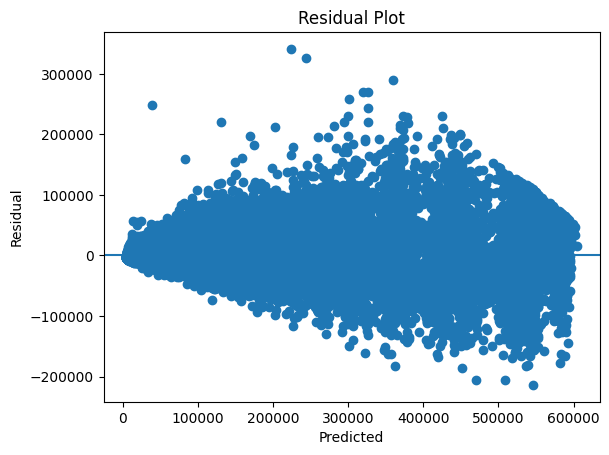

In [53]:
sample_pd = pred_rf.select("trips", "prediction") \
    .sample(fraction=0.05, seed=42) \
    .toPandas()

sample_pd["residual"] = sample_pd["trips"] - sample_pd["prediction"]

plt.figure()
plt.scatter(sample_pd["prediction"], sample_pd["residual"])
plt.xlabel("Predicted")
plt.ylabel("Residual")
plt.title("Residual Plot")
plt.axhline(0)
plt.show()